<a href="https://colab.research.google.com/github/SeanNamUIUC/Semiconductor-AnomalyDetection/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# EDA for Semiconductor Sensor Dataset
# =====================================


# 1. import numpy, pandas, matplotlib, seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. matplotlib inline 설정
%matplotlib inline


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls

drive  sample_data


In [4]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/Semiconductor-AnomalyDetection/data/raw/secom.data"
LABEL_PATH = "/content/drive/MyDrive/Semiconductor-AnomalyDetection/data/raw/secom_labels.data"

X = pd.read_csv(DATA_PATH, sep=" ", header=None)
y = pd.read_csv(LABEL_PATH, header=None)

print(X.shape, y.shape)

(1567, 590) (1567, 1)


In [5]:
!find /content/drive/MyDrive/Semiconductor-AnomalyDetection -name "secom.data"

/content/drive/MyDrive/Semiconductor-AnomalyDetection/data/raw/secom.data


In [6]:
#Data loading


# 1. 데이터 파일 경로 설정
data_path = "/content/drive/MyDrive/Semiconductor-AnomalyDetection/data/raw/secom.data"
label_path = "/content/drive/MyDrive/Semiconductor-AnomalyDetection/data/raw/secom_labels.data"
#dataset description: https://archive.ics.uci.edu/dataset/179/secom

#label data format : [label]  [timestamp(string)]

# 2. pandas로 데이터 로드
df_data1 = pd.read_csv(data_path, header=None)
df_data2 = pd.read_csv(data_path, sep=" ", header=None)
df_data3 = pd.read_csv(data_path, sep="\s+", engine="python", header=None) # 공백하나이상일시 컬럼

df_label1 = pd.read_csv(label_path, header=None)
df_label2 = pd.read_csv(label_path, sep=" ", header=None)


# 3. 데이터 shape 출력
# print(df_data1.shape)
# print(df_data2.shape)
# print(df_data3.shape)
# print(df_label1.shape)


print(df_data2.shape)
print(df_label2.shape)


# print(df_label2.shape)
# print(df_label2.tail())
print(df_data2.head())
print(df_label2.head())
df_data2.info()
df_label2.info()



<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-661850304.py:14: SyntaxWarning: invalid escape sequence '\s'
  df_data3 = pd.read_csv(data_path, sep="\s+", engine="python", header=None) # 공백하나이상일시 컬럼


(1567, 590)
(1567, 2)
       0        1          2          3       4      5         6       7    \
0  3030.93  2564.00  2187.7333  1411.1265  1.3602  100.0   97.6133  0.1242   
1  3095.78  2465.14  2230.4222  1463.6606  0.8294  100.0  102.3433  0.1247   
2  2932.61  2559.94  2186.4111  1698.0172  1.5102  100.0   95.4878  0.1241   
3  2988.72  2479.90  2199.0333   909.7926  1.3204  100.0  104.2367  0.1217   
4  3032.24  2502.87  2233.3667  1326.5200  1.5334  100.0  100.3967  0.1235   

      8       9    ...     580       581     582     583     584      585  \
0  1.5005  0.0162  ...     NaN       NaN  0.5005  0.0118  0.0035   2.3630   
1  1.4966 -0.0005  ...  0.0060  208.2045  0.5019  0.0223  0.0055   4.4447   
2  1.4436  0.0041  ...  0.0148   82.8602  0.4958  0.0157  0.0039   3.1745   
3  1.4882 -0.0124  ...  0.0044   73.8432  0.4990  0.0103  0.0025   2.0544   
4  1.5031 -0.0031  ...     NaN       NaN  0.4800  0.4766  0.1045  99.3032   

      586     587     588       589  
0     Na

In [7]:
#master_df 형태
#|sample_id|timestamp|sensors(1 - 590)|label|


df_data = df_data2
df_label = df_label2

assert len(df_data) == len(df_label)
assert df_data.index.equals(df_label.index)

# feature_df schema 정리 -> ex) sensor_0 , sensor_1 ....
new_data_cols = [f"sensor_{i:03d}" for i in range(1, 591)]
df_data.columns = new_data_cols

# label_df schema 정리
new_label_cols = ["label", "timestamp"]
df_label.columns = new_label_cols
df_label["label"] = df_label["label"].astype("category") # to reduce memory by changing dtype as category
df_label["timestamp"] = pd.to_datetime(df_label["timestamp"]) # to sort by datetime in future


#check revised data and labels
# print(df_data[:5])
# print(df_label[:5])

# → dataframe merge
# → master_df 생성 merge(공통 키 있을떄 유리) vs concat(이어 붙힐떄)
master_df = pd.concat([df_data, df_label], axis = 1)


# Column 재정렬
cols = master_df.columns.to_list()
cols.remove("timestamp")
cols.insert(0, "timestamp")
master_df = master_df[cols]
# print(master_df[:5])

#sample id 생성후 삽입
master_df.insert(0,
                 "sample_id",
                 ["sample_" + str(i + 1).zfill(4) for i in range(len(master_df))])
# print(master_df[1500:])

#data/processed/ 데이터저장
data_processed_parquet_path = "drive/MyDrive/Semiconductor-AnomalyDetection/data/processed/master_df.parquet"
data_processed_csv_path = "drive/MyDrive/Semiconductor-AnomalyDetection/data/processed/master_df.csv"
master_df.to_parquet(data_processed_parquet_path, index=False)
master_df.to_csv(data_processed_csv_path, index=False)

temp = pd.read_parquet(data_processed_parquet_path)
print((temp['label'] == 1). sum())



/tmp/ipython-input-669084287.py:19: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_label["timestamp"] = pd.to_datetime(df_label["timestamp"]) # to sort by datetime in future


104


In [25]:
#1
# 1. Data Structure Analysis

#(sample, features)
print(master_df.shape)

# range of datetime
start_time = master_df['timestamp'].min()
end_time = master_df['timestamp'].max()
print(start_time, end_time)

(1567, 593)
2008-07-19 11:55:00 2008-10-17 06:07:00


         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
..          ...              ...         ...
573  sensor_574         0.000000         574
574  sensor_575         0.000000         575
575  sensor_576         0.000000         576
576  sensor_577         0.000000         577
577  sensor_578         0.000000         578

[590 rows x 3 columns]
Top 20 Sensors by Missing Percentage
         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
220  sensor_221        85.577537         221
358  sensor_359        85.577537         359
492  sensor_493        85.577537       

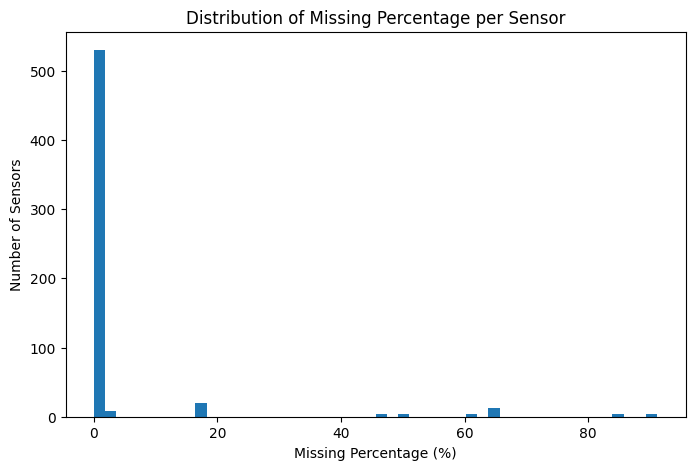


  50% 이상 결측 센서 개수: 28
         sensor  missing_percent  sensor_num
157  sensor_158        91.193363         158
158  sensor_159        91.193363         159
292  sensor_293        91.193363         293
293  sensor_294        91.193363         294
85   sensor_086        85.577537          86
220  sensor_221        85.577537         221
358  sensor_359        85.577537         359
492  sensor_493        85.577537         493
109  sensor_110        64.964901         110
110  sensor_111        64.964901         111
111  sensor_112        64.964901         112
244  sensor_245        64.964901         245
245  sensor_246        64.964901         246
246  sensor_247        64.964901         247
382  sensor_383        64.964901         383
383  sensor_384        64.964901         384
384  sensor_385        64.964901         385
516  sensor_517        64.964901         517
517  sensor_518        64.964901         518
518  sensor_519        64.964901         519
578  sensor_579        60.561583

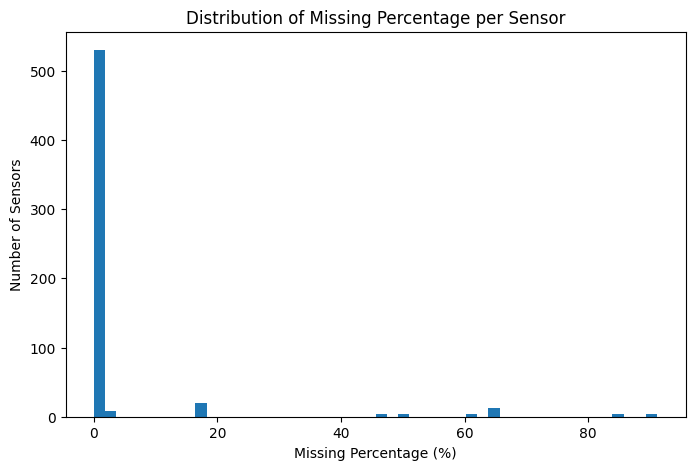

In [67]:


# 2. Missing Values (결측치 심층 분석),

#센서별 결측치 비율 계산
sensor_cols = [cols for cols in master_df.columns if cols.startswith("sensor_")]
missing_percentage_per_cols = (master_df[sensor_cols].isnull().mean() * 100 ) #boolean values .mean() -> 전체 대비 True값들의 비율


#sorted_missing_percentage_per_cols changed datatype from series to dataframe to sort both key and value
missing_df = missing_percentage_per_cols.reset_index()
missing_df.columns = ["sensor", "missing_percent"]

#add sensor_number for sorting
missing_df["sensor_num"] = (
     missing_df["sensor"]
    .apply(lambda x: x.split("_")[1]) #숫자만 빼내서 정렬
    .astype(int)
)

sorted_missing_percentage_per_cols = missing_df.sort_values(
    by=["missing_percent", "sensor_num"],
    ascending=[False, True]
)
print(sorted_missing_percentage_per_cols)


print("Top 20 Sensors by Missing Percentage")
print(sorted_missing_percentage_per_cols.head(20))

#히스토그램
plt.figure(figsize=(8, 5))
plt.hist(missing_percentage_per_cols, bins=50)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Sensors")
plt.title("Distribution of Missing Percentage per Sensor")
plt.show()


# 7. 50% 이상 결측 센서
high_missing = sorted_missing_percentage_per_cols[sorted_missing_percentage_per_cols["missing_percent"] >= 50]

print("\n  50% 이상 결측 센서 개수:", len(high_missing))
print(high_missing)

# 8. 80% 이상 결측 센서
very_high_missing = sorted_missing_percentage_per_cols[sorted_missing_percentage_per_cols["missing_percent"] >= 80]

print("\n  80% 이상 결측 센서 개수:", len(very_high_missing))
print(very_high_missing)

# 9. 히스토그램 시각화
plt.figure(figsize=(8,5))
plt.hist(missing_df["missing_percent"], bins=50)
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Number of Sensors")
plt.title("Distribution of Missing Percentage per Sensor")
plt.show()


# multi key sorting, group pattern analysis, histogram based on sensors



In [26]:
# 3. Label Analysis
num_total = len(master_df['label'])
num_defective = (master_df['label'] == 1).sum()
num_finished = (master_df['label'] == -1).sum()
print("defective_product percentage is", ((num_defective / num_total) * 100 ))
master_df['timestamp'].is_monotonic_increasing




# Report
#New SECOM data is composed with 1567 samples and 591features including label and sample_id we created.
#This data is based on 3months. Defective_product percentage is 6.64% which shows that this data is highly unbalanced. Also we checked that the timestamp is sorted.

defective_product percentage is 6.636885768985322


True